In [1]:

from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "NOTEBOOKS":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "DATA"
RAW_DIR = DATA_DIR / "RAW"
PROCESSED_DIR = DATA_DIR / "PROCESSED"
MODELS_DIR = PROJECT_ROOT / "MODELS"
OUTPUTS_DIR = PROJECT_ROOT / "OUTPUTS"
PLOTS_DIR = OUTPUTS_DIR / "PLOTS"

for d in [PROCESSED_DIR, MODELS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib

X_train = pd.read_csv(PROCESSED_DIR / "X_train_selected.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_selected.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze("columns").astype(int)
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze("columns").astype(int)

selected_features = X_train.columns.tolist()
print("Training features:", selected_features)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Project root: C:\Users\sitar\Downloads\ASSIGNMENT_CODE\PREDICTIVE-MAINTENANCE
Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Training features: ['rotational_speed_[rpm]', 'tool_wear_[min]', 'air_temperature_[k]', 'type', 'twf', 'pwf', 'process_temperature_[k]', 'hdf', 'rnf', 'osf']
Train shape: (8000, 10)
Test shape: (2000, 10)


In [2]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

              precision    recall  f1-score   support

           0     0.9767    0.9979    0.9872      1932
           1     0.8462    0.3235    0.4681        68

    accuracy                         0.9750      2000
   macro avg     0.9114    0.6607    0.7276      2000
weighted avg     0.9723    0.9750    0.9695      2000

ROC-AUC: 0.9149


,importance
rotational_speed_[rpm],0.430906
tool_wear_[min],0.269485
air_temperature_[k],0.155085
process_temperature_[k],0.118492
type,0.026032
twf,0.000000
pwf,0.000000
hdf,0.000000
rnf,0.000000
osf,0.000000


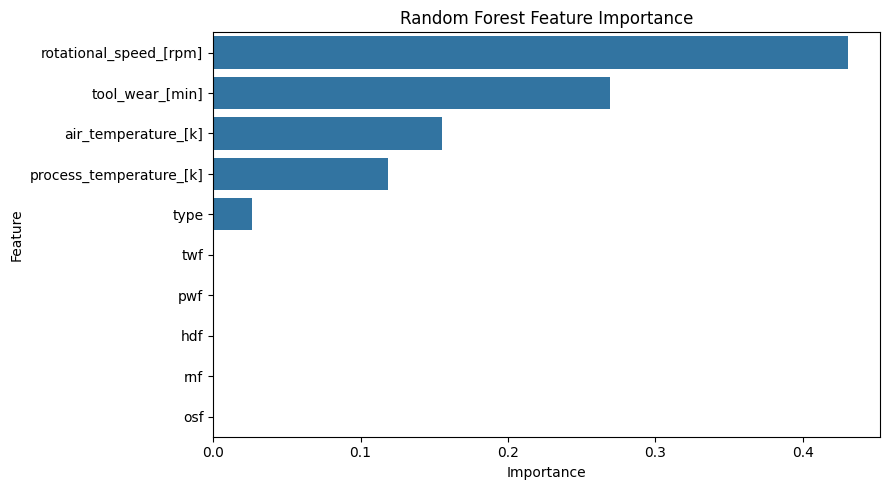

Saved model to: C:\Users\sitar\Downloads\ASSIGNMENT_CODE\PREDICTIVE-MAINTENANCE\MODELS\predictive_maintenance_model.joblib


In [3]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=selected_features).sort_values(ascending=False)
display(importance.to_frame("importance"))

plt.figure(figsize=(9,5))
sns.barplot(x=importance.values, y=importance.index)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

model_path = MODELS_DIR / "predictive_maintenance_model.joblib"
joblib.dump({
    "model": model,
    "features": selected_features
}, model_path)

print("Saved model to:", model_path)